# Подготовка и расширенный анализ `json_data`

Ноутбук собирает JSON-бенчмарки в `raw_df`, `time_df`, `topology_df`, `merged_df` и `metrics_long_df`, а затем добавляет статистические и визуальные сравнения алгоритмов: ANOVA, PCA, кластеризацию, масштабируемость, radar charts, корреляции и визуальные примеры лабиринтов.


In [36]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [37]:
DATA_DIR_CANDIDATES = [Path("json_data"), Path("analisys/json_data")]
DATA_DIR = next((path for path in DATA_DIR_CANDIDATES if path.exists()), Path("json_data"))
EXAMPLE_MAZES_PATH = DATA_DIR / "examples" / "maze_examples.json"

ALGORITHM_LABELS = {
    "binary_tree": "Binary Tree",
    "dfs": "DFS",
    "growing_tree": "Growing Tree",
    "prim": "Prim",
    "recursive_division": "Recursive Division",
    "watson": "Watson",
}

PERFORMANCE_METRICS = [
    "steps_count",
    "memory_peak_bytes",
]

TOPOLOGY_METRICS = [
    "steps_count",
    "memory_peak_bytes",
    "wall_density",
    "dead_end_count",
    "dead_end_ratio",
    "branch_ratio",
    "corridor_ratio",
    "avg_degree",
    "cycle_count",
    "diameter",
    "longest_path",
    "symmetry_score",
    "fractal_dimension",
    "aspl",
    "entropy",
]

ANALYSIS_METRICS = ["generation_us"] + TOPOLOGY_METRICS

KEY_COLUMNS = [
    "benchmark",
    "algorithm",
    "algorithm_label",
    "columns",
    "rows",
    "seed",
    "cells",
    "aspect_ratio",
]


def algorithm_label(name: str) -> str:
    return ALGORITHM_LABELS.get(name, name.replace("_", " ").title())


def ensure_columns(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    for column in columns:
        if column not in df.columns:
            df[column] = np.nan
    return df


def available_metrics(df: pd.DataFrame, metrics: list[str] = ANALYSIS_METRICS) -> list[str]:
    return [metric for metric in metrics if metric in df.columns and df[metric].notna().any()]


def load_raw_df(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    """Загружает все JSON-файлы с агрегированными метриками в один DataFrame."""
    records = []
    
    for path in sorted(data_dir.glob("*.json")):
        algorithm = path.stem
        payload = json.loads(path.read_text(encoding="utf-8"))
        if not isinstance(payload, list):
            continue
        
        for entry in payload:
            if not {"columns", "rows", "seed"}.issubset(entry):
                continue
            row = dict(entry)
            row["benchmark"] = algorithm
            row["algorithm"] = algorithm
            row["algorithm_label"] = algorithm_label(algorithm)
            row["cells"] = row["columns"] * row["rows"]
            row["aspect_ratio"] = row["columns"] / row["rows"]
            records.append(row)
    
    raw_df = pd.DataFrame(records)
    if raw_df.empty:
        return raw_df

    raw_df = ensure_columns(raw_df, ["microseconds", "all_pairs_connected"] + TOPOLOGY_METRICS)
    raw_df = raw_df.sort_values(
        ["algorithm", "columns", "rows", "seed"]
    ).reset_index(drop=True)
    
    for column in ["aspl", "entropy"]:
        if column in raw_df.columns:
            raw_df[column] = raw_df[column].replace(-1, np.nan)
    
    return raw_df


def build_time_df(raw_df: pd.DataFrame) -> pd.DataFrame:
    return (
        raw_df[["algorithm", "algorithm_label", "columns", "rows", "seed", "cells", "aspect_ratio", "microseconds"]]
        .rename(columns={"microseconds": "generation_us"})
        .reset_index(drop=True)
    )


def build_topology_df(raw_df: pd.DataFrame) -> pd.DataFrame:
    raw_df = ensure_columns(raw_df.copy(), TOPOLOGY_METRICS)
    return raw_df[
        ["algorithm", "algorithm_label", "columns", "rows", "seed", "cells", "aspect_ratio", "all_pairs_connected"] + TOPOLOGY_METRICS
    ].reset_index(drop=True)


def build_merged_df(time_df: pd.DataFrame, topology_df: pd.DataFrame) -> pd.DataFrame:
    return topology_df.merge(
        time_df.drop(columns=["algorithm_label"]),
        on=[
            "algorithm",
            "columns",
            "rows",
            "seed",
            "cells",
            "aspect_ratio",
        ],
        how="inner",
    ).reset_index(drop=True)


def build_metrics_long_df(merged_df: pd.DataFrame) -> pd.DataFrame:
    metric_columns = ["generation_us", "all_pairs_connected"] + TOPOLOGY_METRICS
    metric_columns = [column for column in metric_columns if column in merged_df.columns]
    long_df = merged_df.melt(
        id_vars=[
            "algorithm",
            "algorithm_label",
            "columns",
            "rows",
            "seed",
            "cells",
            "aspect_ratio",
        ],
        value_vars=metric_columns,
        var_name="metric",
        value_name="value",
    )

    long_df["metric_group"] = np.select(
        [
            long_df["metric"].eq("generation_us"),
            long_df["metric"].isin(PERFORMANCE_METRICS),
            long_df["metric"].eq("all_pairs_connected"),
        ],
        ["time", "performance", "connectivity"],
        default="topology",
    )
    return long_df.sort_values(
        ["metric", "algorithm", "columns", "rows", "seed"]
    ).reset_index(drop=True)


In [38]:
raw_df = load_raw_df()
time_df = build_time_df(raw_df)
topology_df = build_topology_df(raw_df)
merged_df = build_merged_df(time_df, topology_df)
metrics_long_df = build_metrics_long_df(merged_df)

In [39]:
print('raw_df:', raw_df.shape)
print('time_df:', time_df.shape)
print('topology_df:', topology_df.shape)
print('merged_df:', merged_df.shape)
print('metrics_long_df:', metrics_long_df.shape)

raw_df: (2280, 25)
time_df: (2280, 8)
topology_df: (2280, 23)
merged_df: (2280, 24)
metrics_long_df: (38760, 10)


In [40]:
raw_df.head()

,columns,rows,seed,microseconds,all_pairs_connected,branch_ratio,steps_count,memory_peak_bytes,wall_density,dead_end_count,...,longest_path,symmetry_score,fractal_dimension,aspl,entropy,benchmark,algorithm,algorithm_label,cells,aspect_ratio
0,21,40,101,9,True,0.239286,840,1160,0.500595,203,...,112,0.543254,1.699886,46.343232,6.421994,binary_tree,binary_tree,Binary Tree,840,0.525
1,21,40,202,9,True,0.242857,840,1160,0.500595,206,...,105,0.538492,1.699886,43.390936,6.326644,binary_tree,binary_tree,Binary Tree,840,0.525
2,21,40,303,8,True,0.240476,840,1160,0.500595,204,...,97,0.544444,1.699886,43.845059,6.264350,binary_tree,binary_tree,Binary Tree,840,0.525
3,21,40,404,8,True,0.234524,840,1160,0.500595,199,...,99,0.546825,1.699886,44.463131,6.243062,binary_tree,binary_tree,Binary Tree,840,0.525
4,21,40,505,9,True,0.245238,840,1160,0.500595,208,...,103,0.544841,1.699886,44.688240,6.338337,binary_tree,binary_tree,Binary Tree,840,0.525


In [41]:
time_df.head()

,algorithm,algorithm_label,columns,rows,seed,cells,aspect_ratio,generation_us
0,binary_tree,Binary Tree,21,40,101,840,0.525,9
1,binary_tree,Binary Tree,21,40,202,840,0.525,9
2,binary_tree,Binary Tree,21,40,303,840,0.525,8
3,binary_tree,Binary Tree,21,40,404,840,0.525,8
4,binary_tree,Binary Tree,21,40,505,840,0.525,9


In [42]:
topology_df.head(10)

,algorithm,algorithm_label,columns,rows,seed,cells,aspect_ratio,all_pairs_connected,steps_count,memory_peak_bytes,...,branch_ratio,corridor_ratio,avg_degree,cycle_count,diameter,longest_path,symmetry_score,fractal_dimension,aspl,entropy
0,binary_tree,Binary Tree,21,40,101,840,0.525,True,840,1160,...,0.239286,0.519048,1.997619,0,112,112,0.543254,1.699886,46.343232,6.421994
1,binary_tree,Binary Tree,21,40,202,840,0.525,True,840,1160,...,0.242857,0.511905,1.997619,0,105,105,0.538492,1.699886,43.390936,6.326644
2,binary_tree,Binary Tree,21,40,303,840,0.525,True,840,1160,...,0.240476,0.516667,1.997619,0,97,97,0.544444,1.699886,43.845059,6.264350
3,binary_tree,Binary Tree,21,40,404,840,0.525,True,840,1160,...,0.234524,0.528571,1.997619,0,99,99,0.546825,1.699886,44.463131,6.243062
4,binary_tree,Binary Tree,21,40,505,840,0.525,True,840,1160,...,0.245238,0.507143,1.997619,0,103,103,0.544841,1.699886,44.688240,6.338337
5,binary_tree,Binary Tree,21,40,606,840,0.525,True,840,1160,...,0.267857,0.461905,1.997619,0,95,95,0.522619,1.699886,42.453902,6.197985
6,binary_tree,Binary Tree,21,40,707,840,0.525,True,840,1160,...,0.260714,0.476190,1.997619,0,109,109,0.523016,1.699886,45.910824,6.359128
7,binary_tree,Binary Tree,21,40,808,840,0.525,True,840,1160,...,0.250000,0.497619,1.997619,0,101,101,0.543651,1.699886,43.783336,6.315396
8,binary_tree,Binary Tree,21,40,909,840,0.525,True,840,1160,...,0.251190,0.495238,1.997619,0,98,98,0.538095,1.699886,42.997185,6.238730
9,binary_tree,Binary Tree,21,40,1010,840,0.525,True,840,1160,...,0.253571,0.490476,1.997619,0,91,91,0.531746,1.699886,42.188104,6.169416


In [43]:
merged_df['cells'].max()

np.int64(10000)

In [44]:
metrics_long_df.head(20)

,algorithm,algorithm_label,columns,rows,seed,cells,aspect_ratio,metric,value,metric_group
0,binary_tree,Binary Tree,21,40,101,840,0.525000,all_pairs_connected,True,connectivity
1,binary_tree,Binary Tree,21,40,202,840,0.525000,all_pairs_connected,True,connectivity
2,binary_tree,Binary Tree,21,40,303,840,0.525000,all_pairs_connected,True,connectivity
3,binary_tree,Binary Tree,21,40,404,840,0.525000,all_pairs_connected,True,connectivity
4,binary_tree,Binary Tree,21,40,505,840,0.525000,all_pairs_connected,True,connectivity
5,binary_tree,Binary Tree,21,40,606,840,0.525000,all_pairs_connected,True,connectivity
6,binary_tree,Binary Tree,21,40,707,840,0.525000,all_pairs_connected,True,connectivity
7,binary_tree,Binary Tree,21,40,808,840,0.525000,all_pairs_connected,True,connectivity
8,binary_tree,Binary Tree,21,40,909,840,0.525000,all_pairs_connected,True,connectivity
9,binary_tree,Binary Tree,21,40,1010,840,0.525000,all_pairs_connected,True,connectivity


In [45]:
seed_101_df = metrics_long_df[metrics_long_df.seed == 101]
seed_101_df

,algorithm,algorithm_label,columns,rows,seed,cells,aspect_ratio,metric,value,metric_group
0,binary_tree,Binary Tree,21,40,101,840,0.525000,all_pairs_connected,True,connectivity
10,binary_tree,Binary Tree,24,35,101,840,0.685714,all_pairs_connected,True,connectivity
20,binary_tree,Binary Tree,28,30,101,840,0.933333,all_pairs_connected,True,connectivity
30,binary_tree,Binary Tree,30,28,101,840,1.071429,all_pairs_connected,True,connectivity
40,binary_tree,Binary Tree,30,48,101,1440,0.625000,all_pairs_connected,True,connectivity
...,...,...,...,...,...,...,...,...,...,...
38710,watson,Watson,100,86,101,8600,1.162791,wall_density,0.500058,topology
38720,watson,Watson,100,90,101,9000,1.111111,wall_density,0.500056,topology
38730,watson,Watson,100,94,101,9400,1.063830,wall_density,0.500053,topology
38740,watson,Watson,100,98,101,9800,1.020408,wall_density,0.500051,topology


Для исследования лабиринтов, надо придумать некоторые критерии, гипотезы о том, какими ОСОБЕННОСТЯМИ обладают алгоритмы.




Начнем с анализа времени, которое тратится на какие общую генерацию

In [46]:
time_metric_df = seed_101_df[seed_101_df["metric_group"] == "time"][["algorithm","cells","value","aspect_ratio"]]
time_metric_df

,algorithm,cells,value,aspect_ratio
25080,binary_tree,840,9,0.525000
25090,binary_tree,840,9,0.685714
25100,binary_tree,840,9,0.933333
25110,binary_tree,840,8,1.071429
25120,binary_tree,1440,14,0.625000
...,...,...,...,...
27310,watson,8600,151446,1.162791
27320,watson,9000,157905,1.111111
27330,watson,9400,172686,1.063830
27340,watson,9800,193021,1.020408


Text(0.5, 1.0, 'Сравнение скорости работы генерации от количества клеток')

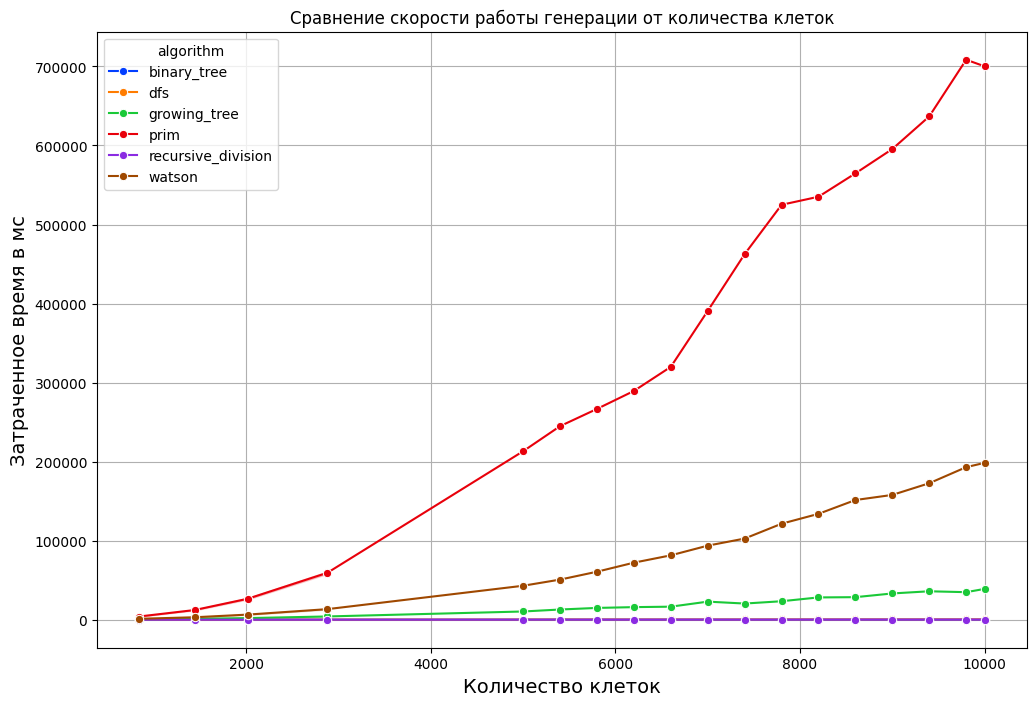

In [47]:
plt.figure(figsize=(12, 8))
ax1 = sns.lineplot(data=time_metric_df, x='cells', y='value', hue='algorithm', marker='o',palette="bright")
ax1.set_xlabel("Количество клеток", fontsize=14)
ax1.grid(True)
ax1.set_ylabel("Затраченное время в мс", fontsize=14)
ax1.set_title("Сравнение скорости работы генерации от количества клеток")

Посмотрим на такое соотношение как увеличение количества времени, при одинаковом количестве клеток, но с другим соотношением(aspect_ratio)

In [48]:
v =sorted(time_metric_df.cells.unique())
# Количество разных значений великовато, возьмем 4 значения
choice_of_cells = []
for i in range(1, len(v), len(v) // 4):
    choice_of_cells.append(v[i])
choice_of_cells.pop(0)
filtered_df = time_metric_df[time_metric_df['cells'].isin(choice_of_cells)]
fil1_df = time_metric_df[time_metric_df['cells'] == 6144]
fil1_df

,algorithm,cells,value,aspect_ratio


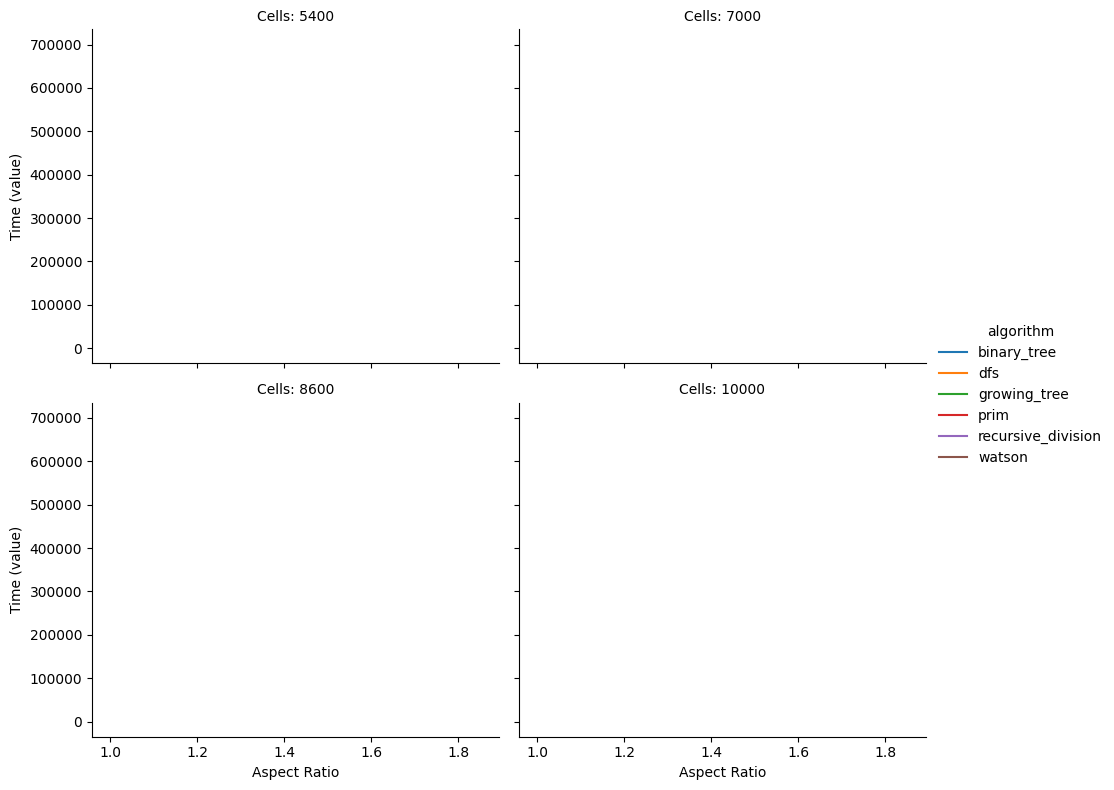

In [49]:
g = sns.relplot(
    data=filtered_df, 
    x='aspect_ratio', 
    y='value', 
    hue='algorithm', 
    col='cells', 
    kind='line', 
    col_wrap=2,  # Разместить по 2 графика в ряд (итого сетка 2x2)
    height=4, 
    aspect=1.2
)

# Настройка осей и заголовков
g.set_axis_labels("Aspect Ratio", "Time (value)")
g.set_titles("Cells: {col_name}")

Text(0.5, 1.0, 'Сравнение скорости работы генерации от количества клеток')

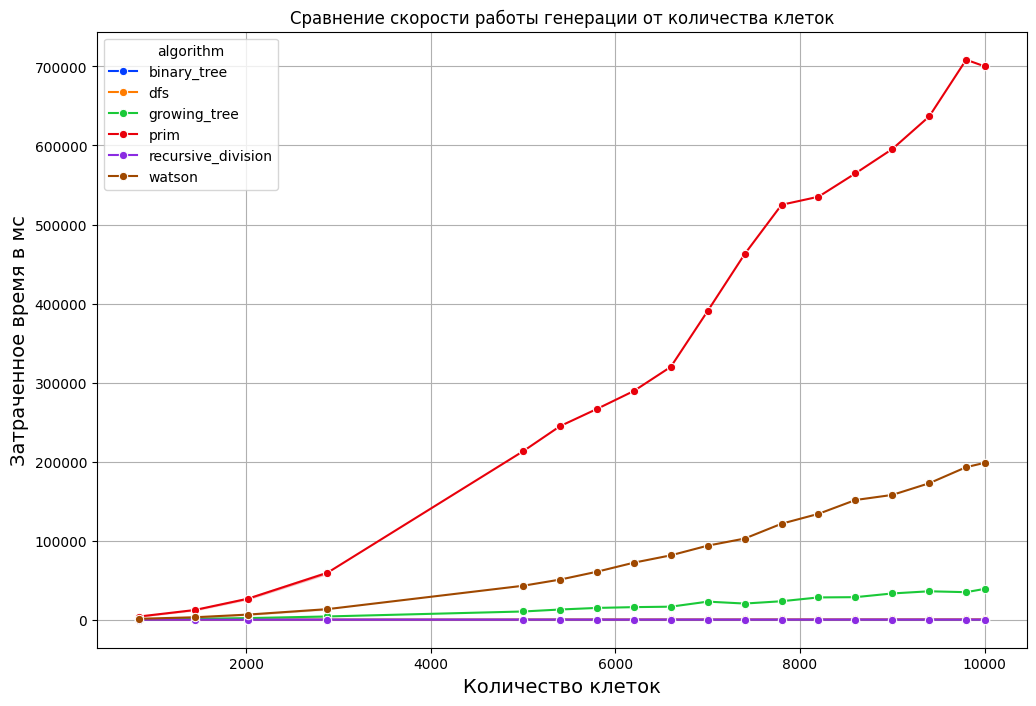

In [50]:
plt.figure(figsize=(12, 8))
ax1 = sns.lineplot(data=time_metric_df, x='cells', y='value', hue='algorithm', marker='o',palette="bright")
ax1.set_xlabel("Количество клеток", fontsize=14)
ax1.grid(True)
ax1.set_ylabel("Затраченное время в мс", fontsize=14)
ax1.set_title("Сравнение скорости работы генерации от количества клеток")

<Axes: xlabel='cells', ylabel='branch_ratio'>

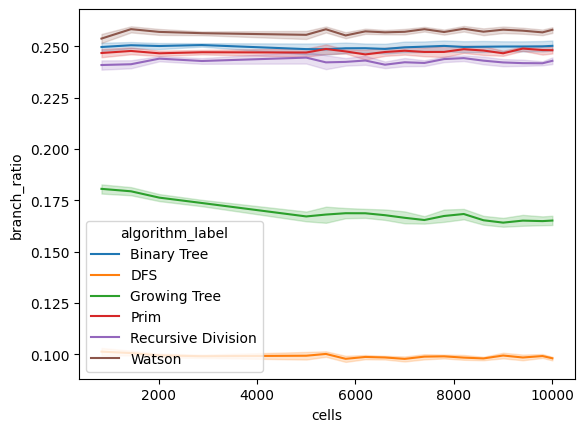

In [51]:
merge_101 = merged_df
# merge_101 = merged_df[merged_df['seed'] == 101]
req_path_of_time = merge_101[["branch_ratio","generation_us","algorithm_label","cells"]]

req_path_of_time.sort_values(ascending=True, by=['generation_us'])
sns.lineplot(req_path_of_time, x='cells', y = 'branch_ratio', hue="algorithm_label")


## Расширенное сравнение алгоритмов

Ниже собраны методы для статистического сравнения, снижения размерности, кластеризации и визуальной проверки структуры лабиринтов.


In [52]:
def summarize_metrics(df: pd.DataFrame, metrics: list[str] = ANALYSIS_METRICS) -> pd.DataFrame:
    metric_columns = available_metrics(df, metrics)
    return (
        df.groupby("algorithm_label")[metric_columns]
        .agg(["mean", "std", "median"])
        .round(4)
    )


def run_anova_tests(df: pd.DataFrame, metrics: list[str] = ANALYSIS_METRICS) -> pd.DataFrame:
    try:
        from scipy import stats
    except ImportError:
        return pd.DataFrame({"note": ["Install scipy to run ANOVA tests."]})

    rows = []
    for metric in available_metrics(df, metrics):
        groups = [
            group[metric].dropna().astype(float).to_numpy()
            for _, group in df.groupby("algorithm_label")
        ]
        groups = [values for values in groups if len(values) > 1]
        if len(groups) < 2:
            continue
        f_stat, p_value = stats.f_oneway(*groups)
        rows.append({"metric": metric, "f_stat": f_stat, "p_value": p_value})

    return pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)


metric_summary_df = summarize_metrics(merged_df)
anova_df = run_anova_tests(merged_df)
anova_df.head(20)


,note
0,Install scipy to run ANOVA tests.


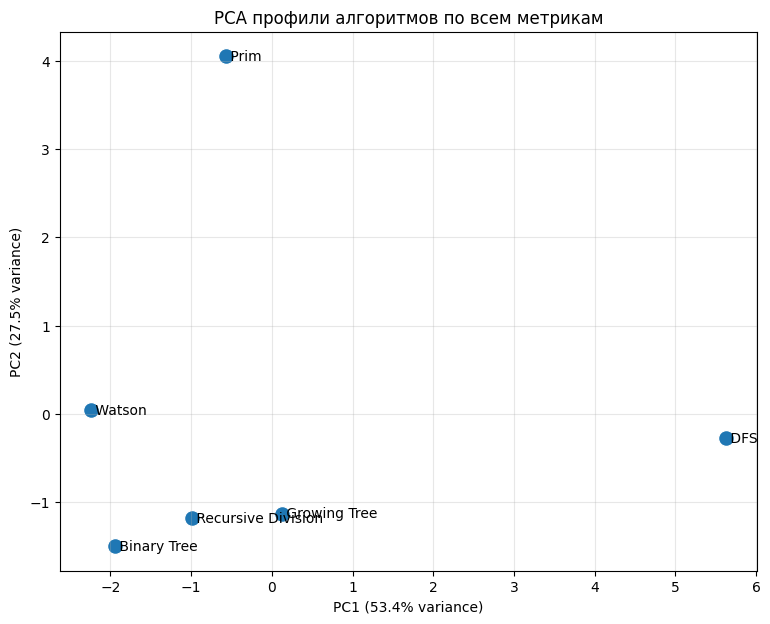

,PC1,PC2
algorithm_label,,
Binary Tree,-1.944185,-1.500583
DFS,5.620452,-0.273753
Growing Tree,0.120662,-1.132270
Prim,-0.574035,4.051033
Recursive Division,-0.988277,-1.182742
Watson,-2.234617,0.038314


In [53]:
def algorithm_metric_matrix(df: pd.DataFrame, metrics: list[str] = ANALYSIS_METRICS) -> pd.DataFrame:
    metric_columns = available_metrics(df, metrics)
    matrix = df.groupby("algorithm_label")[metric_columns].mean(numeric_only=True)
    return matrix.dropna(axis=1, how="all")


def zscore_frame(frame: pd.DataFrame) -> pd.DataFrame:
    std = frame.std(ddof=0).replace(0, np.nan)
    return ((frame - frame.mean()) / std).fillna(0.0)


def compute_pca(matrix: pd.DataFrame, components: int = 2) -> tuple[pd.DataFrame, pd.DataFrame, np.ndarray]:
    scaled = zscore_frame(matrix)
    x = scaled.to_numpy(dtype=float)
    u, singular_values, vt = np.linalg.svd(x, full_matrices=False)
    k = min(components, vt.shape[0])
    scores = pd.DataFrame(
        u[:, :k] * singular_values[:k],
        index=matrix.index,
        columns=[f"PC{i + 1}" for i in range(k)],
    )
    loadings = pd.DataFrame(
        vt[:k].T,
        index=matrix.columns,
        columns=[f"PC{i + 1}" for i in range(k)],
    )
    explained = (singular_values ** 2) / np.sum(singular_values ** 2)
    return scores, loadings, explained[:k]


def plot_pca(scores: pd.DataFrame, explained: np.ndarray) -> None:
    if {"PC1", "PC2"}.issubset(scores.columns):
        plt.figure(figsize=(9, 7))
        sns.scatterplot(data=scores.reset_index(), x="PC1", y="PC2", s=130)
        for label, row in scores.iterrows():
            plt.text(row["PC1"], row["PC2"], f" {label}", va="center")
        plt.xlabel(f"PC1 ({explained[0] * 100:.1f}% variance)")
        plt.ylabel(f"PC2 ({explained[1] * 100:.1f}% variance)")
        plt.title("PCA профили алгоритмов по всем метрикам")
        plt.grid(True, alpha=0.3)
        plt.show()


metric_matrix = algorithm_metric_matrix(merged_df)
pca_scores_df, pca_loadings_df, pca_explained = compute_pca(metric_matrix)
plot_pca(pca_scores_df, pca_explained)
pca_scores_df


In [57]:
scaled_metric_matrix = zscore_frame(metric_matrix)
sns.clustermap(
    scaled_metric_matrix,
    cmap="vlag",
    center=0,
    figsize=(12, 7),
    linewidths=0.4,
)
plt.suptitle("Кластеризация алгоритмов по нормализованным метрикам", y=1.02)
plt.show()


RuntimeError: clustermap requires scipy to be available

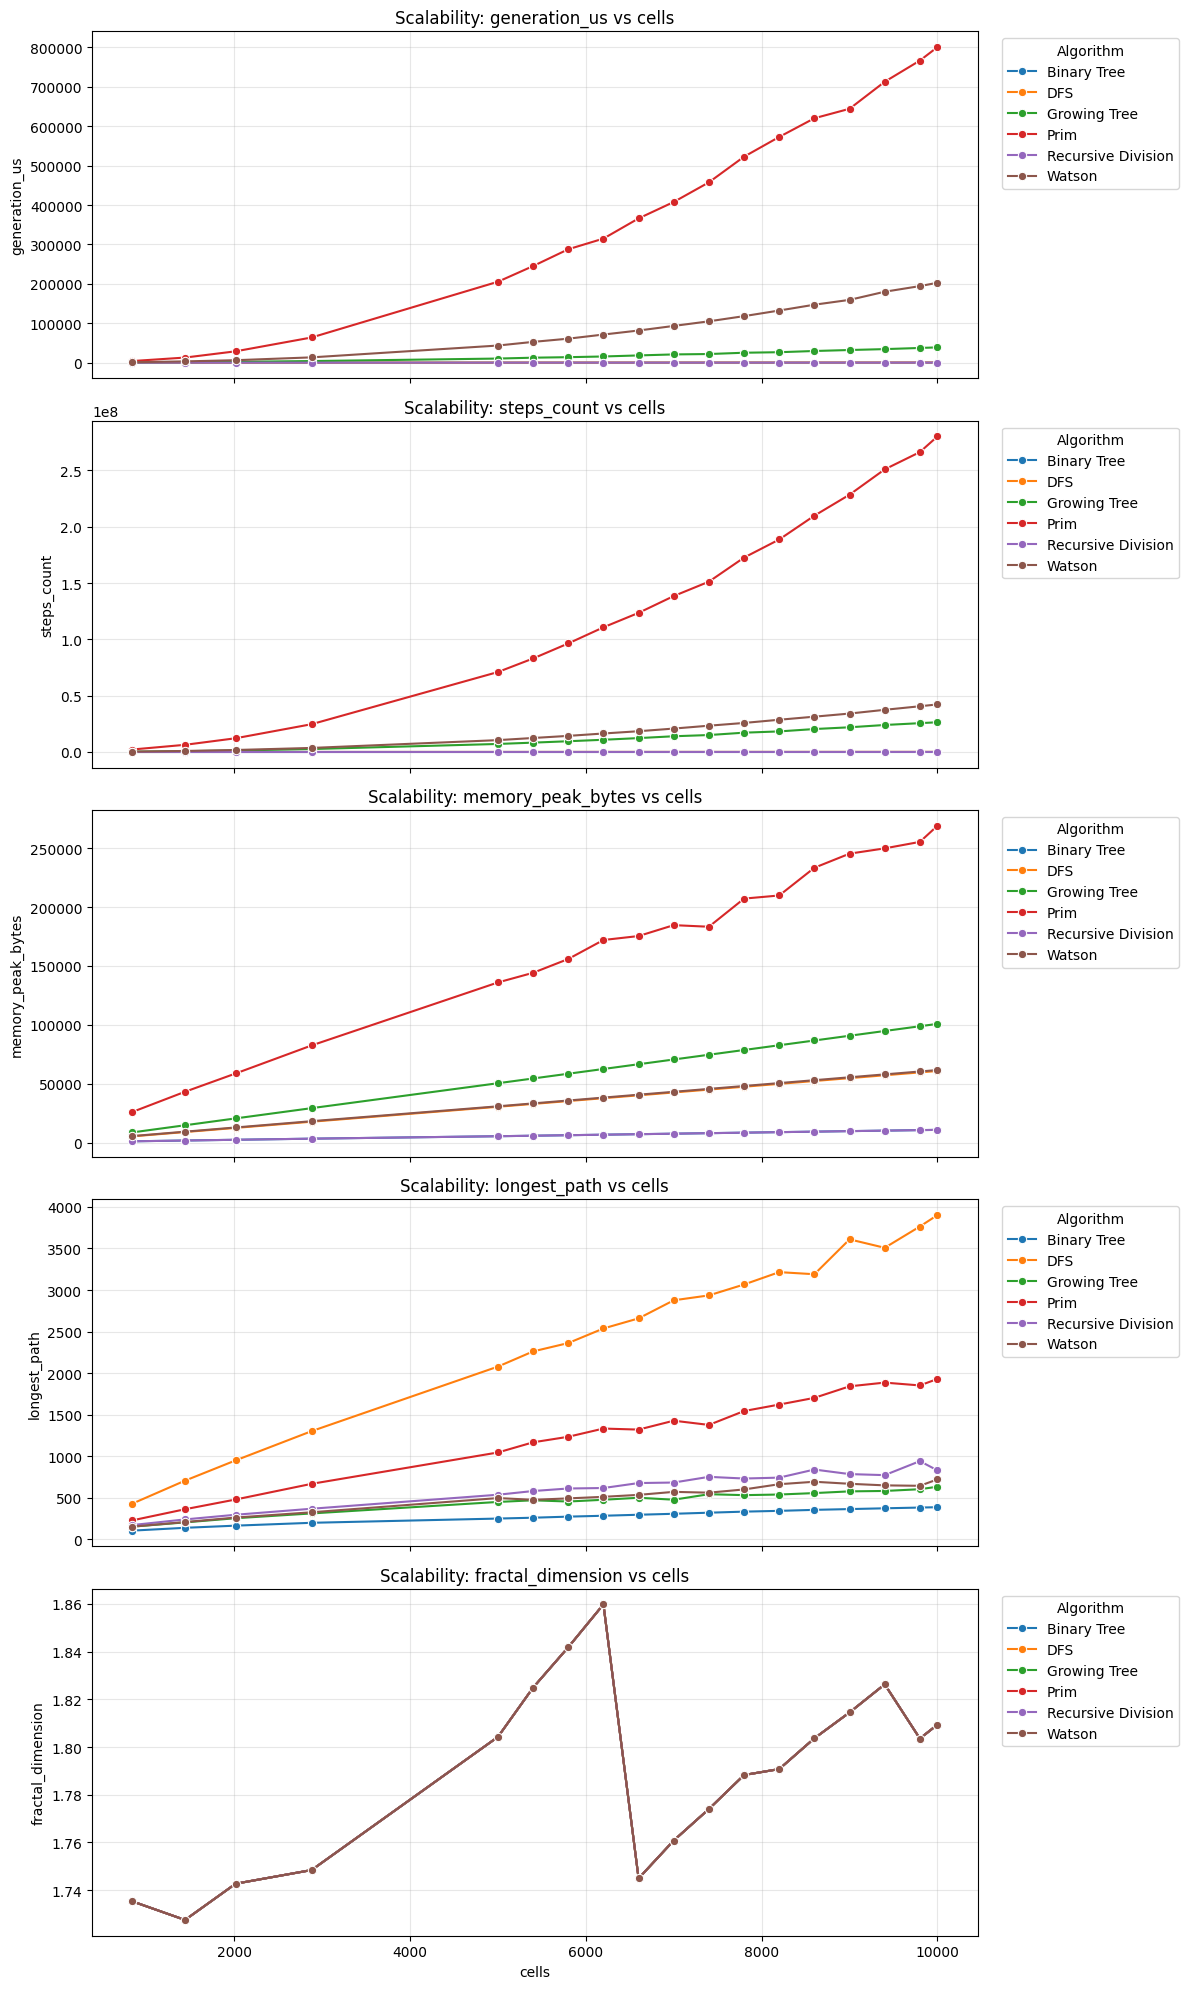

In [56]:
def plot_scalability(
    df: pd.DataFrame,
    metrics: tuple[str, ...] = ("generation_us", "steps_count", "memory_peak_bytes", "longest_path", "fractal_dimension"),
) -> None:
    metrics = tuple(metric for metric in metrics if metric in df.columns)
    fig, axes = plt.subplots(len(metrics), 1, figsize=(12, 4 * len(metrics)), sharex=True)
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        plot_df = (
            df.groupby(["algorithm_label", "cells"], as_index=False)[metric]
            .mean(numeric_only=True)
            .dropna()
        )
        sns.lineplot(data=plot_df, x="cells", y=metric, hue="algorithm_label", marker="o", ax=ax)
        ax.set_title(f"Scalability: {metric} vs cells")
        ax.grid(True, alpha=0.3)
        ax.legend(title="Algorithm", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()


plot_scalability(merged_df)


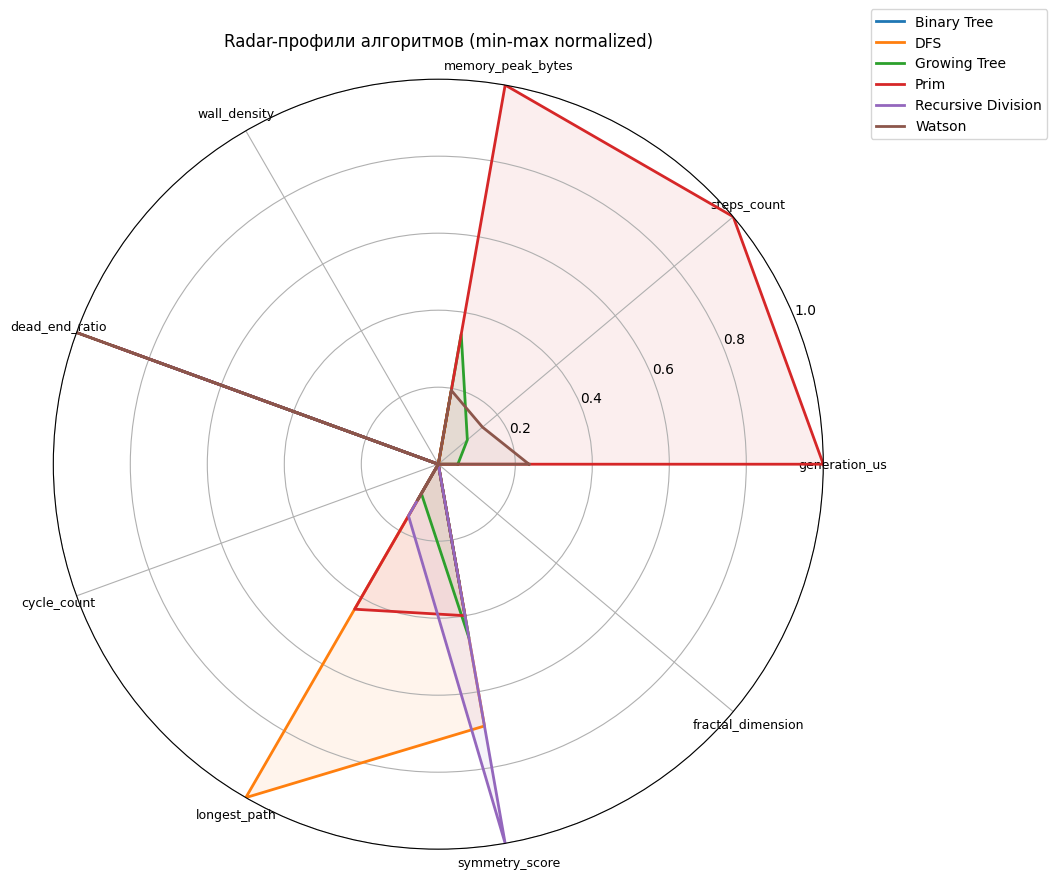

In [55]:
def plot_radar_profiles(
    df: pd.DataFrame,
    metrics: list[str] | None = None,
) -> None:
    if metrics is None:
        metrics = [
            "generation_us",
            "steps_count",
            "memory_peak_bytes",
            "wall_density",
            "dead_end_ratio",
            "cycle_count",
            "longest_path",
            "symmetry_score",
            "fractal_dimension",
        ]
    metrics = available_metrics(df, metrics)
    profile = df.groupby("algorithm_label")[metrics].mean(numeric_only=True)
    normalized = (profile - profile.min()) / (profile.max() - profile.min()).replace(0, np.nan)
    normalized = normalized.fillna(0.0)

    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, polar=True)
    for algorithm, values in normalized.iterrows():
        series = values.tolist() + values.tolist()[:1]
        ax.plot(angles, series, label=algorithm, linewidth=2)
        ax.fill(angles, series, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title("Radar-профили алгоритмов (min-max normalized)", pad=24)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.show()


plot_radar_profiles(merged_df)


In [ ]:
corr_metrics = available_metrics(merged_df, ANALYSIS_METRICS)
correlation_df = merged_df[corr_metrics].corr(numeric_only=True)

plt.figure(figsize=(13, 11))
sns.heatmap(correlation_df, cmap="vlag", center=0, annot=False, square=True)
plt.title("Корреляции между метриками")
plt.tight_layout()
plt.show()


In [ ]:
def load_maze_examples(path: Path = EXAMPLE_MAZES_PATH) -> list[dict]:
    if not path.exists():
        print(f"No maze examples found at {path}. Run `make run` to generate them.")
        return []
    return json.loads(path.read_text(encoding="utf-8"))


def plot_maze_examples(examples: list[dict]) -> None:
    if not examples:
        return
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()
    for ax, example in zip(axes, examples):
        ascii_rows = example["ascii"]
        image = np.array([[1 if char == "#" else 0 for char in row] for row in ascii_rows])
        ax.imshow(image, cmap="binary", interpolation="nearest")
        ax.set_title(algorithm_label(example["algorithm"]))
        ax.axis("off")
    for ax in axes[len(examples):]:
        ax.axis("off")
    plt.suptitle("Качественное сравнение: примеры лабиринтов")
    plt.tight_layout()
    plt.show()


maze_examples = load_maze_examples()
plot_maze_examples(maze_examples)
